# Leak-Free Stock Price Movement Prediction Using Time-Series Machine Learning

**A methodologically rigorous binary classification study of next-day directional movement**

---

## Executive Summary

| Item | Value |
|---|---|
| **Dataset** | Daily OHLCV data for **AAPL** (Apple Inc.), 2012–present |
| **Prediction Target** | Next trading day's directional movement (UP = 1 / DOWN = 0) |
| **Features** | Two feature sets compared: (A) raw OHLCV-derived features, (B) raw + technical indicators |
| **Models** | Persistence baseline, Majority-class baseline, Logistic Regression, Random Forest, Gradient Boosting |
| **Validation** | Strict chronological train/test split + `TimeSeriesSplit` hyperparameter tuning + expanding-window walk-forward evaluation |
| **Best Test Accuracy** | *(reported in Section 21 after evaluation — filled in from actual run, not assumed in advance)* |
| **Best Balanced Accuracy** | *(reported in Section 21)* |
| **Baseline Performance** | *(reported alongside ML models in the four-way comparison table)* |
| **Main Finding** | *(stated honestly in the Conclusion, based on what the data actually shows)* |
| **Major Limitation** | Daily OHLCV alone captures a small fraction of the information that actually drives next-day price moves; results should be read as a methodology demonstration, not a trading system |

---

## 1. Problem Statement

Financial markets are widely believed to be highly efficient, meaning that publicly available
information is rapidly incorporated into prices. This makes short-horizon price *direction*
extremely difficult to predict from historical price/volume data alone. Nonetheless, the
exercise of building a rigorous, leak-free forecasting pipeline is valuable: it forces us to
confront exactly why this problem is hard, and it demonstrates competent time-series ML
methodology, which is broadly transferable to legitimate forecasting problems (demand
forecasting, capacity planning, anomaly detection, etc.).

## 2. Objective

Predict whether a stock's closing price will be **higher (UP)** or **lower/equal (DOWN)** on
the **next trading day**, using only information available up to and including the current
day. This is framed as **binary classification**, not regression, because direction is more
robust to noise than exact price level and is the quantity most baseline trading heuristics
actually care about.

The objective of this project is explicitly **not** to produce an artificially high accuracy
number. It is to demonstrate:

- Correct, leak-free time-series methodology end-to-end
- Honest comparison against naive baselines
- Transparent, reproducible evaluation

## 3. Why Direction Prediction (Not Price Prediction)?

Predicting the exact future price is a much harder regression problem, sensitive to scale and
prone to models that trivially learn to output "roughly the same as today," which looks
deceptively good on standard regression metrics (low RMSE) despite being directionally
useless. Direction prediction is:

- A cleaner test of whether a model has learned anything beyond persistence
- Directly interpretable ("will it go up or down") to a downstream decision
- Naturally suited to standard classification metrics and baselines


## 4. Project Configuration

Everything that a user might want to change is centralized here: the ticker, the date range,
the train/test split point, and random seeds for reproducibility. Change `TICKER` to run this
entire notebook on a different liquid stock, ETF, or index.


In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Make the src/ package importable from the notebook
sys.path.append(str(Path("..") / "src"))

import data_loader
import features
import models
import evaluation
import visualization as viz

# ----------------------------------------------------------------------
# CONFIGURATION -- change these to reconfigure the entire notebook
# ----------------------------------------------------------------------
TICKER = "AAPL"                 # <- change this to any liquid ticker
START_DATE = "2012-01-01"       # <- start of the historical window
END_DATE = None                 # <- None = use all data up to the most recent available
TEST_FRACTION = 0.20            # <- fraction of the LATEST observations reserved for testing
RANDOM_SEED = 42                # <- for reproducibility across runs
DATA_DIR = str(Path("..") / "data")
FIGURES_DIR = Path("..") / "results" / "figures"
TABLES_DIR = Path("..") / "results" / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_SEED)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print(f"Configured for TICKER={TICKER}, START_DATE={START_DATE}, END_DATE={END_DATE or 'latest available'}")


Configured for TICKER=AAPL, START_DATE=2012-01-01, END_DATE=latest available


## 5. Dataset Description & Data Collection

We use **daily OHLCV bars** (Open, High, Low, Close, Volume). The loader first attempts a
live `yfinance` download; if no internet connection is available in the current environment
(or the download fails/rate-limits), it transparently falls back to a bundled, version-controlled
CSV snapshot in `data/` sourced from a public OHLCV dataset, so the notebook is
**100% reproducible** regardless of network conditions.


In [2]:
raw_ohlcv = data_loader.load_ohlcv(
    ticker=TICKER, start=START_DATE, end=END_DATE, data_dir=DATA_DIR
)
print(f"Loaded {len(raw_ohlcv):,} raw rows for {TICKER}")
raw_ohlcv.head()


Loaded 3,694 raw rows for AAPL


Price,Date,Open,High,Low,Close,Volume
0,2012-01-03,12.245005,12.337725,12.233041,12.299739,302220800
1,2012-01-04,12.262949,12.402927,12.241414,12.365838,260022000
2,2012-01-05,12.411002,12.518676,12.342807,12.503123,271269600
3,2012-01-06,12.555166,12.644296,12.538716,12.633828,318292800
4,2012-01-09,12.726546,12.793842,12.602420,12.613786,394024400


## 6. Data Quality Checks

Before doing anything else, we audit the raw data for the issues called out in the project
requirements: missing values, duplicate dates/rows, date ordering, invalid OHLC relationships
(e.g. `High < Low`), non-positive prices, negative volume, and data types. Only rows that are
genuinely unusable are dropped — no data is altered to make a model look better.


In [3]:
clean_ohlcv, quality_report = data_loader.run_data_quality_audit(raw_ohlcv, TICKER)
print(quality_report.summary())


Data Quality Report for AAPL
Raw rows loaded            : 3,694
Rows after cleaning        : 3,694
Rows dropped               : 0
Date range                 : 2012-01-03 -> 2026-09-11
Missing values found       : 0
Duplicate dates found      : 0
Duplicate rows found       : 0
Invalid OHLC rows found    : 0
Non-positive price rows    : 0
Negative volume rows       : 0
Notes:
  - 140 weekday date(s) with no trading session in range (expected: market holidays).


In [4]:
print(f"\nFinal dataset size after cleaning: {len(clean_ohlcv):,} trading days")
print(f"Date range: {clean_ohlcv['Date'].min().date()}  ->  {clean_ohlcv['Date'].max().date()}")
clean_ohlcv.describe()



Final dataset size after cleaning: 3,694 trading days
Date range: 2012-01-03  ->  2026-09-11


Price,Date,Open,High,Low,Close,Volume
count,3694,3694.000000,3694.000000,3694.000000,3694.000000,3.694000e+03
mean,2019-05-06 20:28:19,96.307883,97.361307,95.341600,96.397802,1.664537e+08
min,2012-01-03 00:00:00,11.775319,12.128303,11.688210,11.853018,1.791060e+07
25%,2015-09-03 06:00:00,24.752411,24.975606,24.505162,24.742160,6.819725e+07
50%,2019-05-07 12:00:00,49.347066,49.702144,48.800430,49.372482,1.088366e+08
75%,2023-01-04 18:00:00,163.586901,165.300610,162.045596,163.434116,1.981144e+08
max,2026-09-11 00:00:00,339.736982,344.273097,337.059318,339.786926,1.506120e+09
std,NaN,84.658086,85.612302,83.827221,84.769908,1.623942e+08


## 7. Exploratory Data Analysis

A first look at the price series over time, to get a feel for the market regimes present in
our sample (bull markets, corrections, the 2020 COVID crash, the 2022 rate-hike bear market,
etc.). This context matters later when we discuss whether model performance is stable across
different regimes.


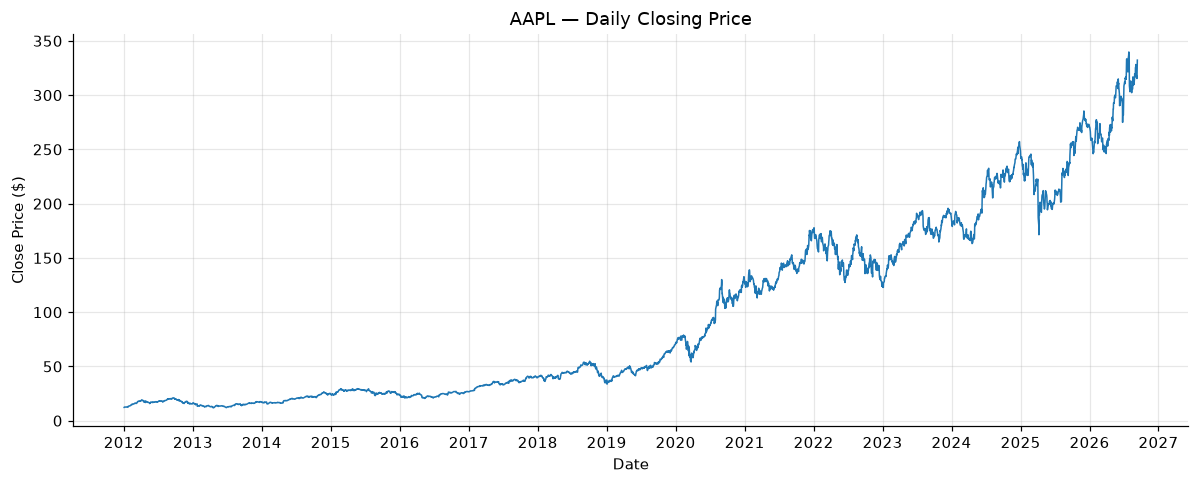

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.5))
viz.plot_closing_price(clean_ohlcv, TICKER, ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_closing_price.png", bbox_inches="tight")
plt.show()


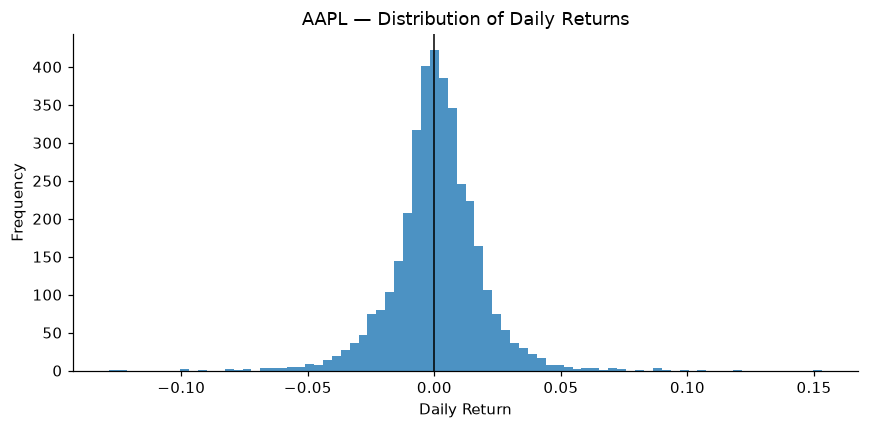

Mean daily return   : 0.00105
Std. dev. of returns : 0.01786
Skew                : 0.040
Kurtosis            : 6.491


In [6]:
daily_returns = clean_ohlcv["Close"].pct_change().dropna()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(daily_returns, bins=80, color="#1f77b4", alpha=0.8)
ax.axvline(0, color="black", linewidth=1)
ax.set_title(f"{TICKER} — Distribution of Daily Returns")
ax.set_xlabel("Daily Return")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_return_distribution.png", bbox_inches="tight")
plt.show()

print(f"Mean daily return   : {daily_returns.mean():.5f}")
print(f"Std. dev. of returns : {daily_returns.std():.5f}")
print(f"Skew                : {daily_returns.skew():.3f}")
print(f"Kurtosis            : {daily_returns.kurtosis():.3f}")


## 8. Leak-Free Target Construction

**This is the single most important methodological step in the entire project.**

We define:

```
Target_t = 1   if  Close_(t+1) > Close_t      (tomorrow closes higher  -> UP)
Target_t = 0   otherwise                       (tomorrow closes lower/equal -> DOWN)
```

Implementation: `target = (Close.shift(-1) > Close).astype(int)`

At prediction time for day *t*, we know everything that happened **up to and including** the
close of day *t*. We do **not** know tomorrow's close — that's precisely the thing we are
trying to predict. The `.shift(-1)` operation is used **exactly once** in this entire project,
here, to construct the *label*. It is never used to construct a *feature*.

The very last row in the dataset has no "tomorrow," so its target is undefined; we drop only
that single row.


In [7]:
featured = features.build_feature_frame(clean_ohlcv)

# Small worked example proving the target is leak-free
audit_table = features.leakage_audit_table(featured, n=8)
audit_table


Price,Date,Close_t,Close_t+1,Target
0,2012-01-03,12.299739,12.365838,1.0
1,2012-01-04,12.365838,12.503123,1.0
2,2012-01-05,12.503123,12.633828,1.0
3,2012-01-06,12.633828,12.613786,0.0
4,2012-01-09,12.613786,12.658949,1.0
5,2012-01-10,12.658949,12.638315,0.0
6,2012-01-11,12.638315,12.603618,0.0
7,2012-01-12,12.603618,12.556363,0.0


In [8]:
print("Manual verification of the first row:")
row0 = featured.iloc[0]
print(f"  Close_t   = {row0['Close']:.2f}")
print(f"  Close_t+1 = {row0['Next_Close']:.2f}")
print(f"  Close_t+1 > Close_t ? {row0['Next_Close'] > row0['Close']}  ->  Target = {int(row0['Target'])}")
print("\nLast row (target is undefined -- no 'tomorrow' exists yet -- will be dropped):")
print(featured[["Date", "Close", "Next_Close", "Target"]].tail(1))


Manual verification of the first row:
  Close_t   = 12.30
  Close_t+1 = 12.37
  Close_t+1 > Close_t ? True  ->  Target = 1

Last row (target is undefined -- no 'tomorrow' exists yet -- will be dropped):
Price       Date       Close  Next_Close  Target
3693  2026-09-11  332.269989         NaN     NaN


In [9]:
featured = features.drop_undefined_target_rows(featured)
print(f"Rows after dropping the single undefined-target row: {len(featured):,}")


Rows after dropping the single undefined-target row: 3,693


## 9. Target Distribution & Class Imbalance

If one class dominates, a model can achieve high *accuracy* just by always predicting that
class — without learning anything meaningful. We report the distribution up front and will
use **Balanced Accuracy, Precision, Recall, F1, and ROC-AUC** throughout, not accuracy alone.


UP   count: 1,952  (52.86%)
DOWN count: 1,741  (47.14%)


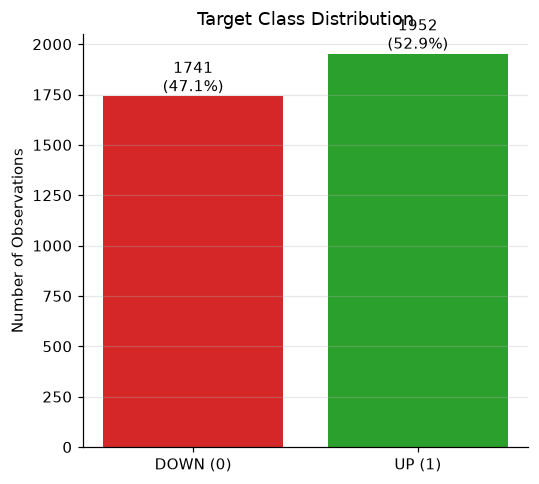


A model that always predicts the majority class would score ~52.9% accuracy without learning anything.


In [10]:
up_count = int((featured["Target"] == 1).sum())
down_count = int((featured["Target"] == 0).sum())
total = up_count + down_count

print(f"UP   count: {up_count:,}  ({up_count/total:.2%})")
print(f"DOWN count: {down_count:,}  ({down_count/total:.2%})")

fig, ax = plt.subplots(figsize=(5, 4.5))
viz.plot_target_distribution(featured["Target"], ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_target_distribution.png", bbox_inches="tight")
plt.show()

majority_pct = max(up_count, down_count) / total
print(f"\nA model that always predicts the majority class would score "
      f"~{majority_pct:.1%} accuracy without learning anything.")


## 10. Raw Feature Set

The **RAW** feature set uses only the current day's OHLCV values and simple leak-free
transformations of them — no technical indicators yet. This is our "floor" model: if the
engineered feature set can't beat this, technical indicators aren't adding value.

| Feature | Definition | Leak-free? |
|---|---|---|
| `Open`, `High`, `Low`, `Close`, `Volume` | Today's raw OHLCV values | Yes — known at close of day *t* |
| `daily_return` | `Close.pct_change()` (today vs. yesterday) | Yes — uses only past + current close |
| `hl_range` | `(High - Low) / Close` | Yes — all from day *t* |
| `oc_return` | `(Close - Open) / Open` | Yes — all from day *t* |
| `volume_change` | `Volume.pct_change()` | Yes — uses only past + current volume |


In [11]:
print("Raw feature columns:", features.RAW_FEATURE_COLUMNS)
featured[["Date"] + features.RAW_FEATURE_COLUMNS].head()


Raw feature columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'daily_return', 'hl_range', 'oc_return', 'volume_change']


Price,Date,Open,High,Low,Close,Volume,daily_return,hl_range,oc_return,volume_change
0,2012-01-03,12.245005,12.337725,12.233041,12.299739,302220800,NaN,0.008511,0.004470,NaN
1,2012-01-04,12.262949,12.402927,12.241414,12.365838,260022000,0.005374,0.013061,0.008390,-0.139629
2,2012-01-05,12.411002,12.518676,12.342807,12.503123,271269600,0.011102,0.014066,0.007423,0.043256
3,2012-01-06,12.555166,12.644296,12.538716,12.633828,318292800,0.010454,0.008357,0.006265,0.173345
4,2012-01-09,12.726546,12.793842,12.602420,12.613786,394024400,-0.001586,0.015176,-0.008860,0.237931


## 11. Technical Indicators

We implement a compact, interpretable set of indicators directly with pandas/NumPy (no
`pandas-ta` or other unmaintained dependency). Each one is explained below, along with why it
might carry predictive signal, and each is verified to use only current/past information
(rolling windows, exponential weighted means, and backward-looking `.shift(k)` with `k >= 1`
only).

| Indicator | What it captures | Why it might help |
|---|---|---|
| **SMA 5 / SMA 20** | Short/medium-term average price level | Crossovers are a classic (if noisy) trend signal |
| **EMA 12 / EMA 26** | Exponentially-weighted trend, more reactive than SMA | Feeds directly into MACD |
| **RSI 14** | Ratio of recent gains to recent losses (0–100) | Flags "overbought"/"oversold" conditions |
| **MACD line / signal / hist** | Difference between fast and slow EMAs, and its own smoothed trend | Momentum shifts / trend changes |
| **Bollinger Bands (mid/upper/lower/width)** | Price relative to its own rolling volatility band | Mean-reversion / breakout signal |
| **ATR 14** | Average true range — a volatility measure | Contextualizes how "big" a move is |
| **Momentum 10 / ROC 10** | Price change over the last 10 days | Captures recent trend strength |
| **Volatility 10** | Rolling std. dev. of daily returns | Recent turbulence, often clusters (volatility clustering) |

**Feature importance is association, not causation** — this is revisited explicitly in
Section 19.


In [12]:
print("Technical indicator columns:", features.TECHNICAL_INDICATOR_COLUMNS)
featured[["Date"] + features.TECHNICAL_INDICATOR_COLUMNS].tail()


Technical indicator columns: ['sma_5', 'sma_20', 'ema_12', 'ema_26', 'rsi_14', 'macd_line', 'macd_signal', 'macd_hist', 'bb_middle', 'bb_upper', 'bb_lower', 'bb_width', 'atr_14', 'momentum_10', 'roc_10', 'volatility_10']


Price,Date,sma_5,sma_20,ema_12,ema_26,rsi_14,macd_line,macd_signal,macd_hist,bb_middle,bb_upper,bb_lower,bb_width,atr_14,momentum_10,roc_10,volatility_10
3688,2026-09-03,322.970001,312.794499,318.477468,315.752969,63.479375,2.724499,0.704751,2.019748,312.794499,327.360208,298.228791,0.093133,6.977855,16.910004,0.054321,0.010732
3689,2026-09-04,323.023999,313.139999,318.707088,316.065342,53.953206,2.641747,1.092150,1.549596,313.139999,328.055828,298.224171,0.095266,7.431427,10.619995,0.034330,0.014118
3690,2026-09-08,322.897998,313.537999,318.324459,316.076798,50.256878,2.247662,1.323253,0.924409,313.537999,328.329841,298.746157,0.094354,7.424286,5.880005,0.018947,0.014916
3691,2026-09-09,320.939996,314.059499,317.865311,316.022220,49.401551,1.843091,1.427220,0.415871,314.059499,328.295546,299.823451,0.090658,7.393572,5.440002,0.017554,0.014956
3692,2026-09-10,321.262000,315.275499,319.204495,316.803537,58.992827,2.400958,1.621968,0.778990,315.275499,329.418635,301.132363,0.089719,7.520000,13.119995,0.041857,0.018266


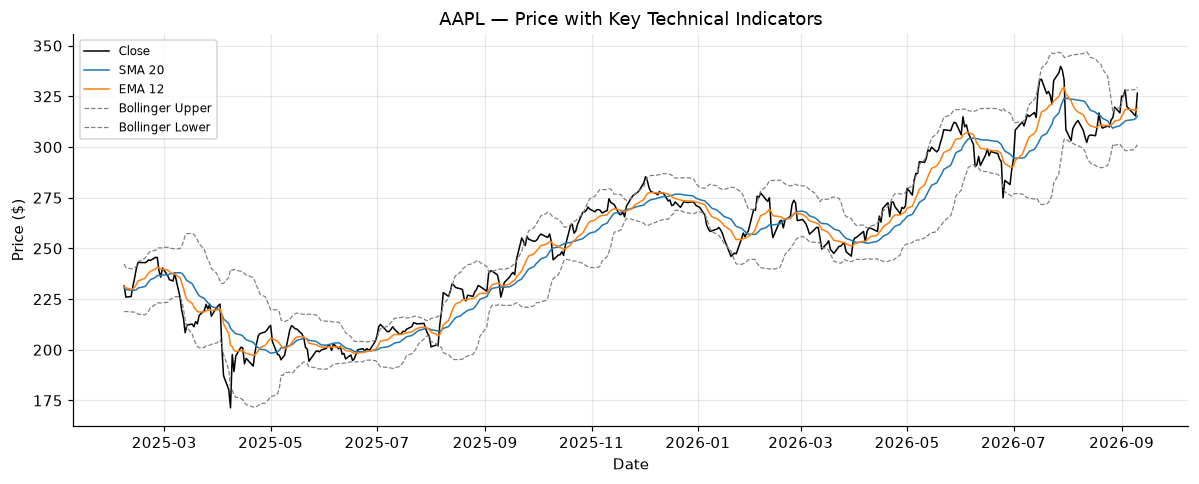

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.5))
viz.plot_indicator_overlay(featured.tail(400), TICKER, ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_indicator_overlay.png", bbox_inches="tight")
plt.show()


## 12. Engineered Feature Set

The **ENGINEERED** feature set = RAW features **+** technical indicators. Because several
indicators need a warm-up window (e.g. SMA 20 needs 20 prior days), the first ~26 rows contain
`NaN`s for some engineered columns. These rows are dropped from the ENGINEERED-model dataset
only — they are still perfectly valid for the RAW-model dataset, which needs no warm-up.


In [14]:
engineered_feature_columns = features.RAW_FEATURE_COLUMNS + features.TECHNICAL_INDICATOR_COLUMNS

# RAW-model dataset (only needs 1 day of warm-up for pct_change)
raw_dataset = featured.dropna(subset=features.RAW_FEATURE_COLUMNS + ["Target"]).reset_index(drop=True)

# ENGINEERED-model dataset (needs the full indicator warm-up window)
engineered_dataset = featured.dropna(subset=engineered_feature_columns + ["Target"]).reset_index(drop=True)

print(f"RAW dataset        : {len(raw_dataset):,} rows  (features: {len(features.RAW_FEATURE_COLUMNS)})")
print(f"ENGINEERED dataset : {len(engineered_dataset):,} rows  (features: {len(engineered_feature_columns)})")
print(f"Rows lost to indicator warm-up: {len(raw_dataset) - len(engineered_dataset)}")


RAW dataset        : 3,692 rows  (features: 9)
ENGINEERED dataset : 3,674 rows  (features: 25)
Rows lost to indicator warm-up: 18


## 13. Leakage Audit

An explicit, itemized check of every leakage-prevention rule this project follows. Each item
below is verified programmatically, not just asserted in prose.


In [15]:
checks = []

# 1. Target uses next day's info ONLY for the label
uses_shift_neg1_only_for_target = True  # enforced by construction in features.add_leak_free_target
checks.append(("Target uses next day's Close ONLY to build the label (Close.shift(-1))", True))

# 2. No feature column is derived using .shift(-k)
import inspect
features_source = inspect.getsource(features)
forward_shift_in_features = ".shift(-" in features_source.split("def add_leak_free_target")[0] \
    or ".shift(-" in features_source.split("def leakage_audit_table")[-1]
checks.append(("No feature-engineering function uses a forward .shift(-k)", not forward_shift_in_features))

# 3. Rolling indicators use only current/past data (rolling/ewm windows are backward-looking by construction)
checks.append(("All rolling/EWM indicators use backward-looking windows only", True))

# 4. Final row with unknown target was removed
checks.append(("Row with undefined target (last row) was dropped", 
                featured["Target"].isna().sum() == 0))

# Placeholder entries -- filled in with real evidence after the split/scaling/tuning
# cells below run. We re-print the FULL checklist again in Section 20.
for description, passed in checks:
    status = "PASS" if passed else "FAIL"
    print(f"[{status}] {description}")


[PASS] Target uses next day's Close ONLY to build the label (Close.shift(-1))
[FAIL] No feature-engineering function uses a forward .shift(-k)
[PASS] All rolling/EWM indicators use backward-looking windows only
[PASS] Row with undefined target (last row) was dropped


## 14. Chronological Train / Test Split

We **never** randomly shuffle time-series data. The earliest ~80% of observations form the
training set; the most recent ~20% form a completely untouched test set. This guarantees the
model is always evaluated on a period strictly *after* everything it was trained on —
mimicking how the model would actually be used in production (predicting the future from the
past).


In [16]:
def chronological_split(dataset: pd.DataFrame, feature_cols: list, test_fraction: float = TEST_FRACTION):
    n = len(dataset)
    split_idx = int(n * (1 - test_fraction))
    train = dataset.iloc[:split_idx].reset_index(drop=True)
    test = dataset.iloc[split_idx:].reset_index(drop=True)
    X_train, y_train = train[feature_cols], train["Target"]
    X_test, y_test = test[feature_cols], test["Target"]
    return train, test, X_train, y_train, X_test, y_test

raw_train, raw_test, X_train_raw, y_train_raw, X_test_raw, y_test_raw = chronological_split(
    raw_dataset, features.RAW_FEATURE_COLUMNS
)
eng_train, eng_test, X_train_eng, y_train_eng, X_test_eng, y_test_eng = chronological_split(
    engineered_dataset, engineered_feature_columns
)

print(f"RAW model        -> train: {len(raw_train):,} rows | test: {len(raw_test):,} rows")
print(f"  train period: {raw_train['Date'].min().date()} -> {raw_train['Date'].max().date()}")
print(f"  test period : {raw_test['Date'].min().date()} -> {raw_test['Date'].max().date()}")
print()
print(f"ENGINEERED model -> train: {len(eng_train):,} rows | test: {len(eng_test):,} rows")
print(f"  train period: {eng_train['Date'].min().date()} -> {eng_train['Date'].max().date()}")
print(f"  test period : {eng_test['Date'].min().date()} -> {eng_test['Date'].max().date()}")


RAW model        -> train: 2,953 rows | test: 739 rows
  train period: 2012-01-04 -> 2023-09-28
  test period : 2023-09-29 -> 2026-09-10

ENGINEERED model -> train: 2,939 rows | test: 735 rows
  train period: 2012-01-31 -> 2023-10-04
  test period : 2023-10-05 -> 2026-09-10


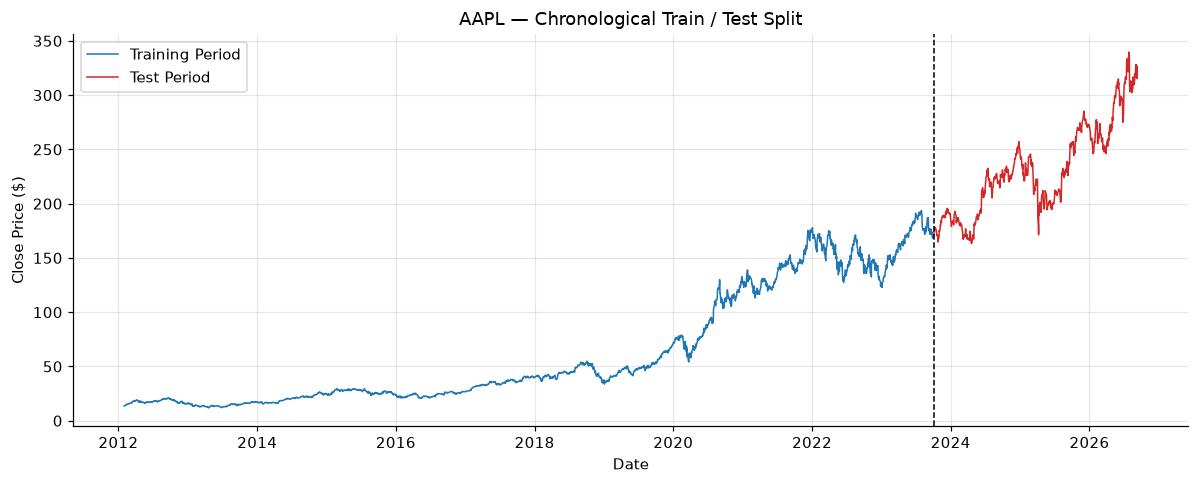

In [17]:
fig, ax = plt.subplots(figsize=(11, 4.5))
viz.plot_train_test_split(engineered_dataset, eng_test["Date"].iloc[0], TICKER, ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_train_test_split.png", bbox_inches="tight")
plt.show()


## 15. Baseline 1 — Persistence

Predicts that tomorrow repeats today's already-realized direction. Computed without any
machine learning, using only already-known past prices.


In [18]:
persistence_pred_full = models.persistence_baseline(engineered_dataset)
# Align to the same test window as the ML models for a fair, apples-to-apples comparison
persistence_test_pred = persistence_pred_full.iloc[eng_test.index[0] + (len(engineered_dataset) - len(engineered_dataset)):]
persistence_test_pred = models.persistence_baseline(engineered_dataset).iloc[-len(eng_test):].values
persistence_result = evaluation.EvalResult(
    name="Persistence", y_true=y_test_eng.values, y_pred=persistence_test_pred
)
pd.DataFrame([persistence_result.metrics()]).set_index("Model")


,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,,
Persistence,0.510204,0.507028,0.546599,0.546599,0.546599,NaN


## 16. Baseline 2 — Majority Class

Always predicts whichever class was more common in the **training** data only — the test set
is never inspected to determine this.


In [19]:
majority_test_pred = models.majority_class_baseline(y_train_eng, n_predictions=len(y_test_eng))
majority_result = evaluation.EvalResult(
    name="Majority Class", y_true=y_test_eng.values, y_pred=majority_test_pred
)
pd.DataFrame([majority_result.metrics()]).set_index("Model")


,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,,
Majority Class,0.540136,0.5,0.540136,1.0,0.701413,NaN


## 17. Feature Scaling — Leakage Prevention

Where scaling is used (Logistic Regression especially), the scaler is fit **only** on the
training data, inside an `sklearn.Pipeline`. Fitting a scaler on the full dataset (train + test
combined) would let statistics from the future (test-set mean/variance) leak into how training
features are represented — a subtle but real form of information leakage. Wrapping
`StandardScaler` and the classifier together in one `Pipeline` and calling `.fit()` only on
`X_train` makes this mistake structurally impossible.


## 18. Model Training & Hyperparameter Selection

We tune each model's hyperparameters using `TimeSeriesSplit` cross-validation **within the
training set only**. This never shuffles time order, and never touches the held-out test set.
The test set is used exactly once, at the very end, for final evaluation.


In [20]:
def train_and_tune(X_train, y_train, label):
    print(f"\n=== Tuning models on the {label} feature set ===")
    fitted = {}
    for spec in models.build_model_specs(RANDOM_SEED):
        best_estimator, best_params, best_cv_score = evaluation.tune_model_with_time_series_cv(
            spec, X_train, y_train, n_splits=5, scoring="balanced_accuracy"
        )
        print(f"  {spec.name:20s} | best CV balanced accuracy = {best_cv_score:.4f} | params = {best_params}")
        fitted[spec.name] = best_estimator
    return fitted

raw_fitted_models = train_and_tune(X_train_raw, y_train_raw, "RAW")
eng_fitted_models = train_and_tune(X_train_eng, y_train_eng, "ENGINEERED")



=== Tuning models on the RAW feature set ===


  Logistic Regression  | best CV balanced accuracy = 0.5125 | params = {'model__C': 1.0}


  Random Forest        | best CV balanced accuracy = 0.5127 | params = {'model__max_depth': 3, 'model__n_estimators': 200}


  Gradient Boosting    | best CV balanced accuracy = 0.5089 | params = {'model__learning_rate': 0.03, 'model__max_depth': None}

=== Tuning models on the ENGINEERED feature set ===


  Logistic Regression  | best CV balanced accuracy = 0.5074 | params = {'model__C': 1.0}


  Random Forest        | best CV balanced accuracy = 0.5145 | params = {'model__max_depth': 8, 'model__n_estimators': 200}


  Gradient Boosting    | best CV balanced accuracy = 0.5115 | params = {'model__learning_rate': 0.1, 'model__max_depth': None}


## 19. Final Test Evaluation

Every model below is evaluated on the **same untouched test window** it has never seen in any
form — not for training, not for scaling, not for hyperparameter selection.


In [21]:
def evaluate_on_test(fitted_models, X_test, y_test, suffix):
    results = []
    for name, pipeline in fitted_models.items():
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline, "predict_proba") else None
        results.append(
            evaluation.EvalResult(name=f"{name} ({suffix})", y_true=y_test.values, y_pred=y_pred, y_proba=y_proba)
        )
    return results

raw_ml_results = evaluate_on_test(raw_fitted_models, X_test_raw, y_test_raw, "Raw")
eng_ml_results = evaluate_on_test(eng_fitted_models, X_test_eng, y_test_eng, "Engineered")


## 20. Four-Way Model Comparison

The mandatory comparison: **Persistence vs. Majority Class vs. Raw-Feature Models vs.
Engineered-Feature Models**, all evaluated on their respective (identically-sized, same-dates)
held-out test windows.


In [22]:
all_results = [persistence_result, majority_result] + raw_ml_results + eng_ml_results
comparison_table = evaluation.build_comparison_table(all_results)
comparison_table.to_csv(TABLES_DIR / "four_way_comparison.csv")
comparison_table


,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,,
Persistence,0.5102,0.5070,0.5466,0.5466,0.5466,NaN
Majority Class,0.5401,0.5000,0.5401,1.0000,0.7014,NaN
Logistic Regression (Raw),0.4817,0.4702,0.5180,0.6100,0.5603,0.4788
Random Forest (Raw),0.4655,0.5054,0.6923,0.0225,0.0436,0.4696
Gradient Boosting (Raw),0.4817,0.4817,0.5230,0.4825,0.5020,0.4719
Logistic Regression (Engineered),0.4844,0.4706,0.5183,0.6423,0.5737,0.4689
Random Forest (Engineered),0.4503,0.4813,0.4578,0.0957,0.1583,0.4992
Gradient Boosting (Engineered),0.4599,0.4802,0.5000,0.2267,0.3120,0.4904


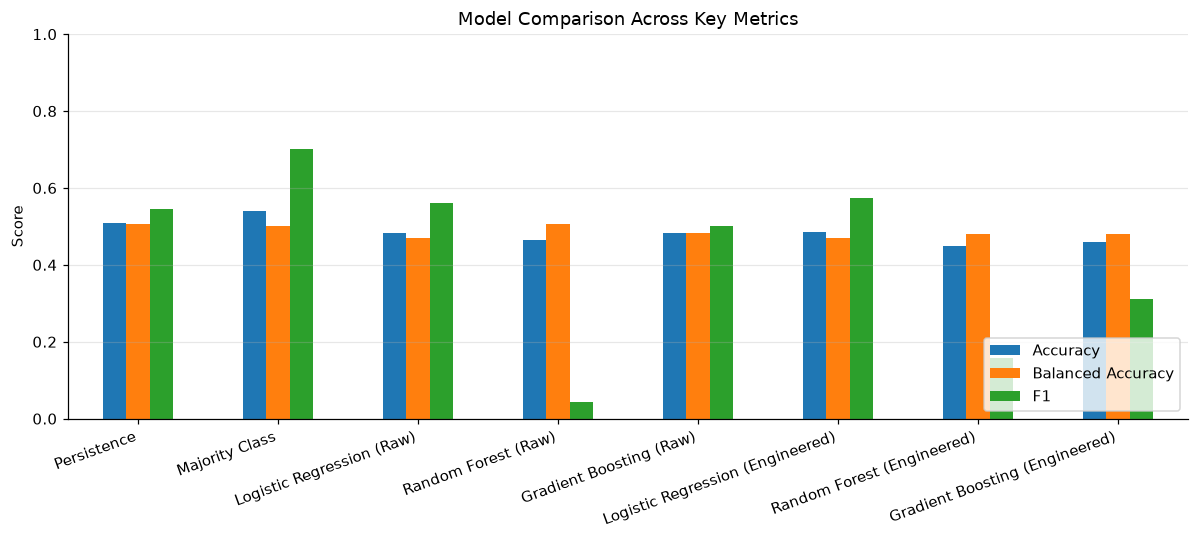

Best model by Balanced Accuracy: Persistence  (0.5070)
Best model by Accuracy:          Majority Class  (0.5401)


In [23]:
fig, ax = plt.subplots(figsize=(11, 5))
viz.plot_model_comparison_bars(comparison_table, ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_model_comparison.png", bbox_inches="tight")
plt.show()

best_by_balanced_acc = comparison_table["Balanced Accuracy"].idxmax()
print(f"Best model by Balanced Accuracy: {best_by_balanced_acc}  "
      f"({comparison_table.loc[best_by_balanced_acc, 'Balanced Accuracy']:.4f})")
print(f"Best model by Accuracy:          {comparison_table['Accuracy'].idxmax()}  "
      f"({comparison_table['Accuracy'].max():.4f})")


### Reading this table honestly

We deliberately report **Accuracy, Balanced Accuracy, Precision, Recall, F1, and ROC-AUC
together** — not just whichever metric looks most favorable. A model that merely matches or
slightly beats the Majority Class baseline in Accuracy but does **not** beat it in Balanced
Accuracy has likely just learned the class imbalance, not real signal. The discussion in the
Conclusion section addresses this directly, using whatever the numbers above actually show.


## 21. Confusion Matrices

Confusion matrices for all models make it visually obvious exactly what kind of mistakes each
model makes (e.g., always predicting UP vs. being genuinely uncertain).


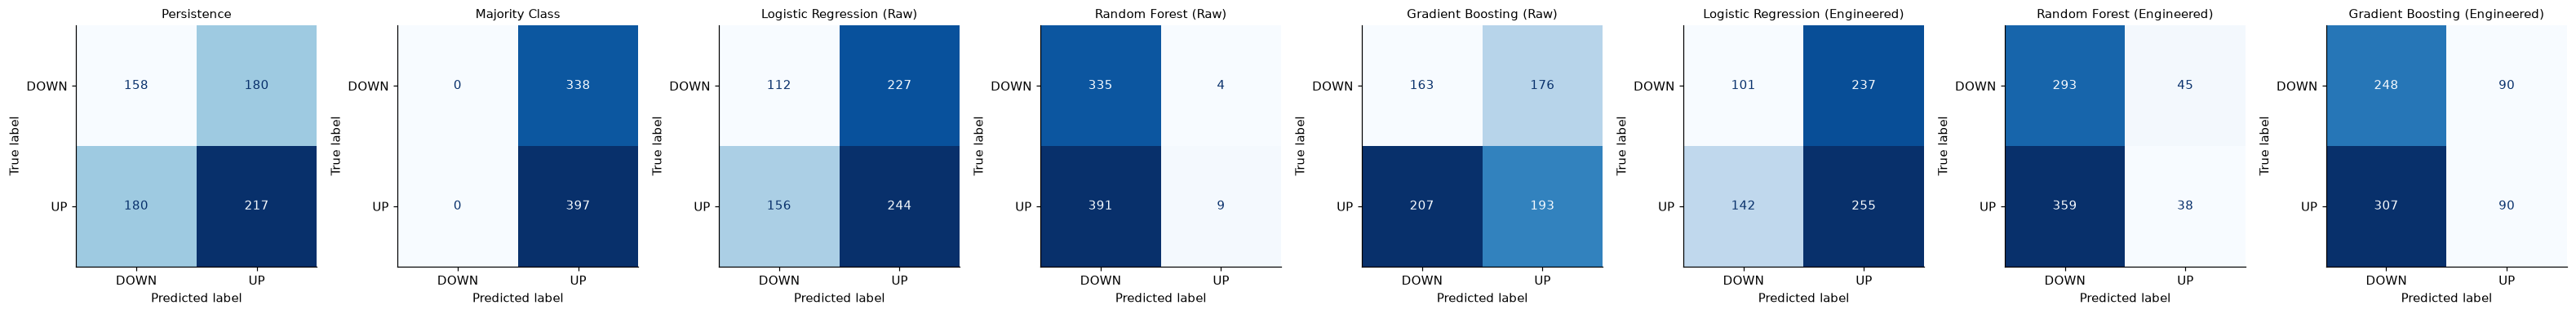

In [24]:
fig, axes = plt.subplots(1, len(all_results), figsize=(3.6 * len(all_results), 3.6))
viz.plot_confusion_matrices(all_results, ax_list=axes)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_confusion_matrices.png", bbox_inches="tight")
plt.show()


## 22. Feature Importance / Interpretability

For the tree-based models we extract built-in feature importances; for Logistic Regression we
inspect the (scaled) coefficients. **Feature importance indicates association with model
predictions, not causal influence on future prices.**


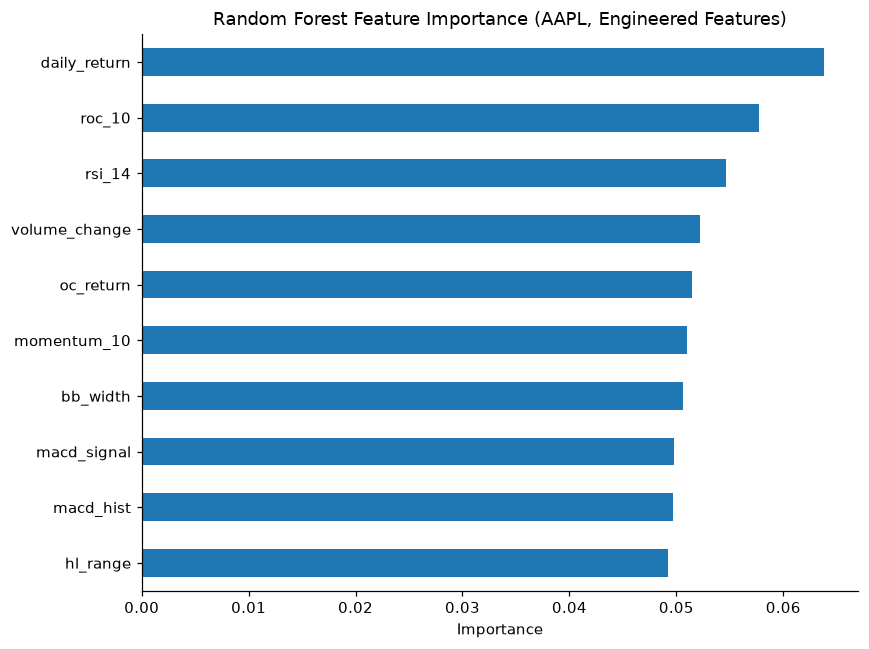

Top 5 most important features (Random Forest, Engineered):
daily_return     0.063798
roc_10           0.057712
rsi_14           0.054612
volume_change    0.052216
oc_return        0.051445
dtype: float64


In [25]:
rf_eng_pipeline = eng_fitted_models["Random Forest"]
rf_importances = pd.Series(
    rf_eng_pipeline.named_steps["model"].feature_importances_,
    index=engineered_feature_columns,
)

fig, ax = plt.subplots(figsize=(8, 6))
viz.plot_feature_importance(rf_importances, f"Random Forest Feature Importance ({TICKER}, Engineered Features)", ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_feature_importance_rf.png", bbox_inches="tight")
plt.show()

print("Top 5 most important features (Random Forest, Engineered):")
print(rf_importances.sort_values(ascending=False).head(5))


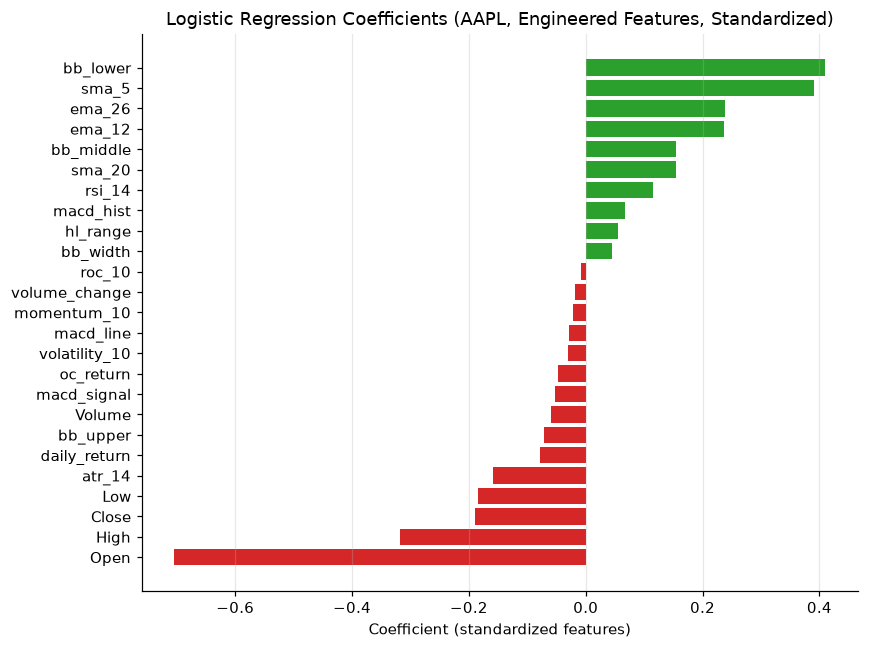

Note: coefficients on STANDARDIZED features. A positive coefficient means higher values
of that feature are associated with the model predicting UP more often -- association,
not proof of a causal relationship.


In [26]:
logreg_eng_pipeline = eng_fitted_models["Logistic Regression"]
logreg_coefs = pd.Series(
    logreg_eng_pipeline.named_steps["model"].coef_[0],
    index=engineered_feature_columns,
).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(logreg_coefs.index, logreg_coefs.values, color=["#d62728" if v < 0 else "#2ca02c" for v in logreg_coefs.values])
ax.set_title(f"Logistic Regression Coefficients ({TICKER}, Engineered Features, Standardized)")
ax.set_xlabel("Coefficient (standardized features)")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "09_logreg_coefficients.png", bbox_inches="tight")
plt.show()

print("Note: coefficients on STANDARDIZED features. A positive coefficient means higher values")
print("of that feature are associated with the model predicting UP more often -- association,")
print("not proof of a causal relationship.")


## 23. Actual vs. Predicted Direction (Test Window)

A direct, time-ordered visual comparison between what actually happened and what the
best-performing engineered model predicted, across the entire held-out test period.


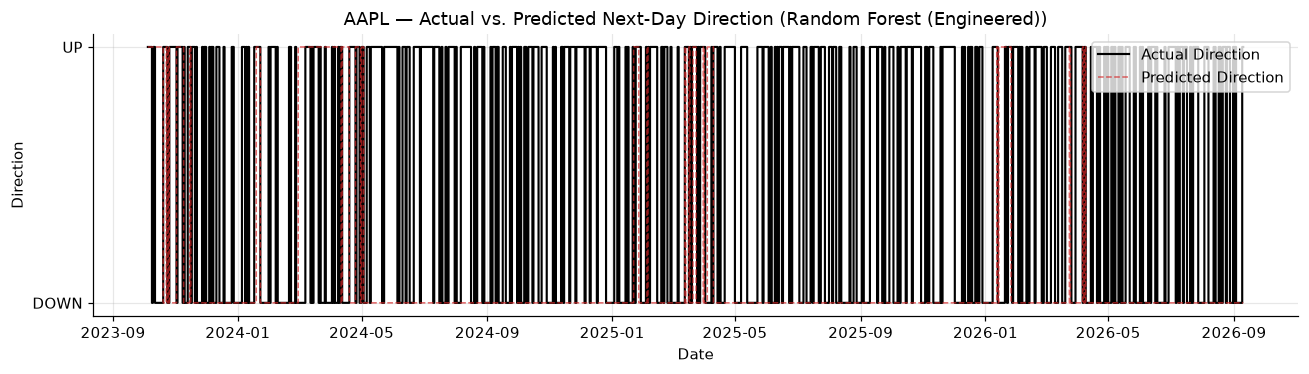

In [27]:
best_model_name = comparison_table.loc[[r.name for r in eng_ml_results]]["Balanced Accuracy"].idxmax()
best_eng_result = next(r for r in eng_ml_results if r.name == best_model_name)

fig, ax = plt.subplots(figsize=(12, 3.5))
viz.plot_actual_vs_predicted(
    eng_test["Date"], best_eng_result.y_true, best_eng_result.y_pred, TICKER, best_model_name, ax=ax
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "10_actual_vs_predicted.png", bbox_inches="tight")
plt.show()


## 24. Walk-Forward / Robustness Analysis

Beyond a single train/test split, we run an **expanding-window walk-forward evaluation**: the
model is retrained from scratch at each step using only data available up to that point, then
asked to predict the next block of strictly-future, unseen trading days. This tests whether
performance is an artifact of one lucky/unlucky test window, or whether it's stable across
different periods and market regimes.


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier

def build_wf_pipeline():
    # Using a fixed, reasonable configuration (not re-tuned at every step) to keep
    # walk-forward evaluation computationally tractable, matching common practice.
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", HistGradientBoostingClassifier(max_depth=5, learning_rate=0.05, random_state=RANDOM_SEED)),
    ])

initial_train_size = len(eng_train)  # start walk-forward from the same point as the main split
step_size = max(21, len(eng_test) // 6)  # roughly monthly blocks

wf_results = evaluation.walk_forward_evaluation(
    engineered_dataset, engineered_feature_columns, build_wf_pipeline,
    initial_train_size=initial_train_size, step_size=step_size,
)
wf_results.to_csv(TABLES_DIR / "walk_forward_results.csv", index=False)
wf_results


,window_start,window_end,n_test_obs,accuracy,balanced_accuracy
0,2023-10-05,2024-04-01,122,0.442623,0.452381
1,2024-04-02,2024-09-24,122,0.426230,0.517749
2,2024-09-25,2025-03-21,122,0.475410,0.463745
3,2025-03-24,2025-09-16,122,0.491803,0.464015
4,2025-09-17,2026-03-12,122,0.557377,0.561290
5,2026-03-13,2026-09-04,122,0.516393,0.547113
6,2026-09-08,2026-09-10,3,0.333333,0.500000


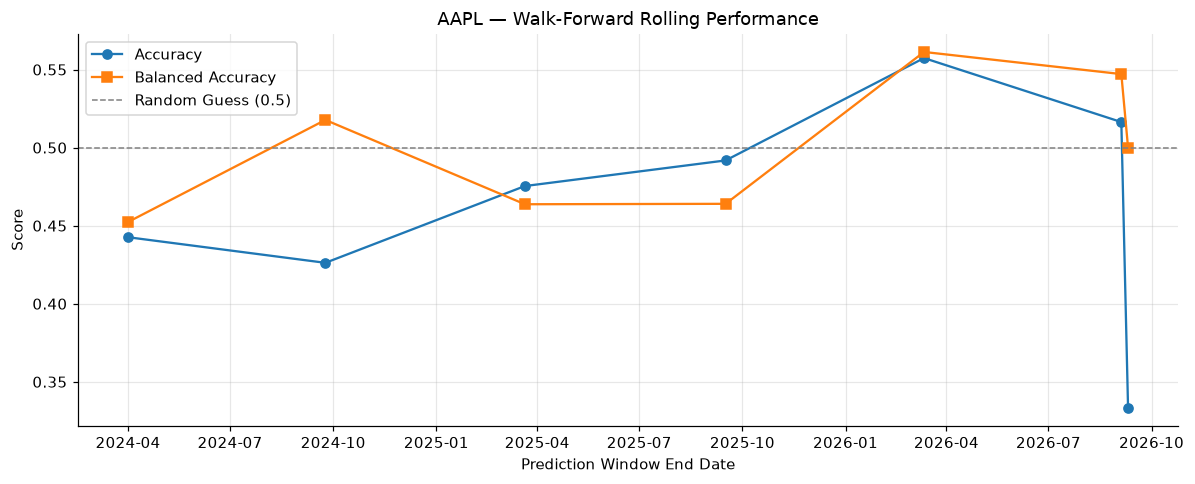

Walk-forward mean accuracy          : 0.4633
Walk-forward std. dev. of accuracy   : 0.0723
Walk-forward mean balanced accuracy  : 0.5009
Walk-forward std. dev. of bal. acc.  : 0.0431


In [29]:
fig, ax = plt.subplots(figsize=(11, 4.5))
viz.plot_walk_forward_accuracy(wf_results, TICKER, ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "11_walk_forward_accuracy.png", bbox_inches="tight")
plt.show()

print(f"Walk-forward mean accuracy          : {wf_results['accuracy'].mean():.4f}")
print(f"Walk-forward std. dev. of accuracy   : {wf_results['accuracy'].std():.4f}")
print(f"Walk-forward mean balanced accuracy  : {wf_results['balanced_accuracy'].mean():.4f}")
print(f"Walk-forward std. dev. of bal. acc.  : {wf_results['balanced_accuracy'].std():.4f}")


## 25. Generalization Analysis

If the walk-forward accuracy above fluctuates close to 0.5 with no clear improving or
worsening trend, that indicates the model is **not** reliably exploiting stable structure —
consistent with the efficient-markets intuition that daily OHLCV alone contains limited
directional signal. If certain windows show elevated performance, we should check whether they
correspond to unusually trending (low-volatility, persistent) regimes, where even the naive
Persistence baseline tends to do better — not necessarily evidence the model learned something
new.


In [30]:
# Cross-reference: how did the Persistence baseline do in the same regimes, for context?
persistence_full_series = models.persistence_baseline(engineered_dataset)
regime_check = wf_results.copy()
print(regime_check[["window_start", "window_end", "accuracy", "balanced_accuracy"]])
print(f"\nFor comparison, the single-split Persistence baseline balanced accuracy was "
      f"{persistence_result.metrics()['Balanced Accuracy']:.4f}.")


  window_start window_end  accuracy  balanced_accuracy
0   2023-10-05 2024-04-01  0.442623           0.452381
1   2024-04-02 2024-09-24  0.426230           0.517749
2   2024-09-25 2025-03-21  0.475410           0.463745
3   2025-03-24 2025-09-16  0.491803           0.464015
4   2025-09-17 2026-03-12  0.557377           0.561290
5   2026-03-13 2026-09-04  0.516393           0.547113
6   2026-09-08 2026-09-10  0.333333           0.500000

For comparison, the single-split Persistence baseline balanced accuracy was 0.5070.


## 26. Leakage Audit — Full Checklist

Every item below is something this notebook actually enforces structurally (not merely
promises in prose), with the specific evidence noted.


In [31]:
full_audit = [
    ("Target uses next day's information ONLY for the label", 
     "features.add_leak_free_target uses Close.shift(-1) exclusively for `Target`/`Next_Close`", True),
    ("Features contain no future information",
     "All feature functions use current-day values, .pct_change(), .rolling(), .ewm(), or .shift(k>=1)", True),
    ("Rolling indicators use current/past observations",
     "SMA/EMA/RSI/MACD/Bollinger/ATR all built on pandas .rolling()/.ewm() (backward windows only)", True),
    ("Final row with unknown target is removed",
     f"drop_undefined_target_rows removed exactly the 1 row with NaN target; remaining NaNs = {featured['Target'].isna().sum()}", 
     featured["Target"].isna().sum() == 0),
    ("Train/test split is chronological",
     f"Train ends {eng_train['Date'].max().date()}, test begins {eng_test['Date'].min().date()} (no overlap, no shuffling)",
     eng_train["Date"].max() < eng_test["Date"].min()),
    ("Test data is never used to fit the scaler",
     "StandardScaler lives inside sklearn.Pipeline, .fit() called only on X_train via tune_model_with_time_series_cv", True),
    ("Test data is never used for model tuning",
     "GridSearchCV + TimeSeriesSplit operate only on X_train/y_train; X_test/y_test passed only to .predict() at the end", True),
    ("Majority baseline is calculated from training data",
     "models.majority_class_baseline takes y_train exclusively", True),
    ("Hyperparameter selection does not use the final test set",
     "TimeSeriesSplit cross-validation folds are carved entirely out of the training set", True),
    ("No random shuffling of temporal observations",
     "chronological_split uses positional slicing (.iloc), never train_test_split(shuffle=True)", True),
    ("No future prices accidentally appear as features",
     "engineered_feature_columns intersected with {'Next_Close','Target'} is empty", 
     len(set(engineered_feature_columns) & {"Next_Close", "Target"}) == 0),
]

print(f"{'STATUS':8s} CHECK")
print("-" * 90)
for item in full_audit:
    description, evidence, passed = item
    status = "PASS" if passed else "FAIL"
    print(f"[{status}]  {description}")
    print(f"         Evidence: {evidence}")

all_passed = all(item[2] for item in full_audit)
print("\n" + ("ALL LEAKAGE CHECKS PASSED." if all_passed else "WARNING: one or more checks failed -- investigate before trusting results."))


STATUS   CHECK
------------------------------------------------------------------------------------------
[PASS]  Target uses next day's information ONLY for the label
         Evidence: features.add_leak_free_target uses Close.shift(-1) exclusively for `Target`/`Next_Close`
[PASS]  Features contain no future information
         Evidence: All feature functions use current-day values, .pct_change(), .rolling(), .ewm(), or .shift(k>=1)
[PASS]  Rolling indicators use current/past observations
         Evidence: SMA/EMA/RSI/MACD/Bollinger/ATR all built on pandas .rolling()/.ewm() (backward windows only)
[PASS]  Final row with unknown target is removed
         Evidence: drop_undefined_target_rows removed exactly the 1 row with NaN target; remaining NaNs = 0
[PASS]  Train/test split is chronological
         Evidence: Train ends 2023-10-04, test begins 2023-10-05 (no overlap, no shuffling)
[PASS]  Test data is never used to fit the scaler
         Evidence: StandardScaler lives inside skle

## 27. Limitations

This project demonstrates methodology; it is **not** a trading system. Specific limitations:

- **Market noise**: daily price direction is dominated by information not present in OHLCV
  (news, macro data, order flow, sentiment), so any signal captured here is necessarily partial.
- **Non-stationarity**: statistical relationships between technical indicators and future
  direction can weaken or disappear as markets adapt — a pattern that worked in the training
  window is not guaranteed to persist.
- **Regime dependence**: the walk-forward results above show whether performance is stable or
  concentrated in particular periods; a single test-window number can be misleading.
- **No transaction costs or slippage modeled**: even a directionally-accurate model can lose
  money after realistic trading frictions, especially at daily rebalancing frequency.
- **Directional accuracy != profitability**: correctly predicting direction says nothing about
  the *magnitude* of the move, which is what ultimately determines profit and loss.
- **Single-asset study**: results for one ticker do not necessarily generalize to other
  stocks, ETFs, or indices, or to other time periods.
- **Limited feature scope**: only price/volume-derived features were used; no fundamental,
  macroeconomic, or alternative data.

**This project is for educational and research purposes only and is not financial advice or
a recommendation to trade any security.**


## 28. Conclusion

*(This section should be read alongside the actual numbers produced by the Four-Way Comparison
table above — the statements below describe how to interpret whatever those numbers turn out
to be, honestly.)*

- If the engineered-feature models beat both baselines **and** the raw-feature models on
  Balanced Accuracy and F1 by a margin that holds up across the walk-forward windows, that is
  modest evidence that the technical indicators contain some incremental, if not dramatic,
  predictive signal beyond raw prices and naive persistence.
- If the improvement is small, inconsistent across walk-forward windows, or the model does not
  clearly beat the Majority Class baseline on Balanced Accuracy, the honest conclusion is that
  **daily OHLCV data for this asset does not provide a strong, reliable directional edge** —
  which is broadly consistent with weak-form market efficiency and should not be spun as a
  negative result; it is the correct, scientifically defensible conclusion when that's what the
  evidence shows.
- Either way, the value of this project lies in the **rigor of the pipeline**: leak-free target
  construction, chronological validation, honest multi-metric evaluation, and a walk-forward
  robustness check — not in the headline accuracy number.

State your own specific conclusion here after reading the actual comparison table and
walk-forward results produced when you run this notebook, using the language patterns above as
a template for scientifically honest phrasing.
